# Random Forest Road Deterioration Baseline

This notebook trains `RandomForestRegressor` models for next-measurement prediction using the same lifecycle-aware modeling dataset and comparable feature groups as the linear baseline notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
DATA_PATH = Path("data/road_model_dataset_v1.parquet")
RANDOM_STATE = 42
TRAIN_SAMPLE_N = 200_000
TEST_SAMPLE_N = 80_000
TRAIN_DATE_QUANTILE = 0.80

In [3]:
use_cols = [
    "event_date",
    "target_next_URA",
    "target_next_IRI",
    "baseline_persist_URA",
    "baseline_persist_IRI",
    "URA",
    "IRI",
    "prev_URA",
    "prev_IRI",
    "Delta_t_years",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
]

df = pd.read_parquet(DATA_PATH, columns=use_cols)
df["event_date"] = pd.to_datetime(df["event_date"])
print(df.shape)
display(df.head())

(3833323, 21)


,event_date,target_next_URA,target_next_IRI,baseline_persist_URA,baseline_persist_IRI,URA,IRI,prev_URA,prev_IRI,Delta_t_years,Pavement_Age_years,Initial_URA,Measurement_Idx,Minor_TP_Count,tp_count_interval,has_TP_interval,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk
0,2018-06-18,2.7,1.93,2.7,1.60,2.7,1.60,NaN,NaN,NaN,0.0,2.7,1,1,1,True,182.0,23.0,80.0,80,yhdys
1,2018-06-18,1.7,1.70,1.4,1.50,1.4,1.50,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys
2,2018-06-18,1.5,1.91,1.5,1.75,1.5,1.75,NaN,NaN,NaN,0.0,1.5,1,1,1,True,182.0,23.0,80.0,80,yhdys
3,2018-06-18,3.5,1.66,4.7,1.45,4.7,1.45,NaN,NaN,NaN,0.0,4.7,1,1,1,True,182.0,23.0,80.0,80,yhdys
4,2018-06-18,2.0,2.96,1.4,2.42,1.4,2.42,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys


In [4]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()

train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")

Cutoff date: 2020-08-18
Train sample rows: 200,000
Test sample rows: 80,000


In [5]:
def regression_metrics(y_true, y_pred, model_name, target_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "model": model_name,
        "target": target_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_true, y_pred),
    }


def split_valid_feature_groups(frame: pd.DataFrame, selected_features):
    available = [c for c in selected_features if c in frame.columns]
    non_empty = [c for c in available if frame[c].notna().any()]
    dropped_all_missing = [c for c in available if c not in non_empty]
    numeric_features = [c for c in non_empty if c != "Toim_lk"]
    categorical_features = [c for c in ["Toim_lk"] if c in non_empty]
    return {
        "available": available,
        "non_empty": non_empty,
        "dropped_all_missing": dropped_all_missing,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def build_preprocessor(feature_groups):
    transformers = []

    if feature_groups["numeric_features"]:
        transformers.append(
            (
                "num",
                SimpleImputer(strategy="median"),
                feature_groups["numeric_features"],
            )
        )

    if feature_groups["categorical_features"]:
        try:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot),
                    ]
                ),
                feature_groups["categorical_features"],
            )
        )

    if not transformers:
        raise ValueError("No valid non-empty feature columns were found for preprocessing.")

    return ColumnTransformer(transformers=transformers)


## Persistence Baseline

In [6]:
rf_results = []

rf_results.append(regression_metrics(test_sample["target_next_URA"], test_sample["baseline_persist_URA"], "persistence", "target_next_URA"))
rf_results.append(regression_metrics(test_sample["target_next_IRI"], test_sample["baseline_persist_IRI"], "persistence", "target_next_IRI"))

pd.DataFrame(rf_results)

,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.136373,2.714789,0.625921
1,persistence,target_next_IRI,0.220080,0.408304,0.832784


## Random Forest Feature Sets

In [7]:
feature_sets = {
    "current_only": ["URA", "IRI"],
    "current_plus_lag": ["URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years"],
    "current_lag_lifecycle": [
        "URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years",
        "Pavement_Age_years", "Initial_URA", "Measurement_Idx", "Minor_TP_Count",
        "tp_count_interval", "has_TP_interval",
    ],
    "current_lag_lifecycle_static": [
        "URA", "IRI", "prev_URA", "prev_IRI", "Delta_t_years",
        "Pavement_Age_years", "Initial_URA", "Measurement_Idx", "Minor_TP_Count",
        "tp_count_interval", "has_TP_interval", "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
}

rf_predictions = {}
rf_feature_importances = {}

In [8]:
for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== Feature set: {feature_set_name} ===")

    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample[target_name].notna()
        test_target = test_sample[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample.columns]
        X_train = train_sample.loc[train_target, active_features].copy()
        y_train = train_sample.loc[train_target, target_name]
        X_test = test_sample.loc[test_target, active_features].copy()
        y_test = test_sample.loc[test_target, target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        print(f"Target: {target_name}")
        print(f"Dropped all-missing features: {feature_groups['dropped_all_missing']}")

        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=200,
                        max_depth=None,
                        min_samples_leaf=5,
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        metrics = regression_metrics(y_test, y_pred, "random_forest", target_name)
        metrics["feature_set"] = feature_set_name
        metrics["n_features_used"] = len(feature_groups["non_empty"])
        rf_results.append(metrics)
        rf_predictions[(feature_set_name, target_name)] = (y_test, y_pred)

        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        importances = pipe.named_steps["model"].feature_importances_
        rf_feature_importances[(feature_set_name, target_name)] = pd.DataFrame(
            {"feature": feature_names, "importance": importances}
        ).sort_values("importance", ascending=False).reset_index(drop=True)

rf_results_df = pd.DataFrame(rf_results).sort_values(["target", "model", "rmse"]).reset_index(drop=True)
rf_results_df


=== Feature set: current_only ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_plus_lag ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle_static ===
Target: target_next_URA
Dropped all-missing features: []
Target: target_next_IRI
Dropped all-missing features: []


,model,target,mae,rmse,r2,feature_set,n_features_used
0,persistence,target_next_IRI,0.220080,0.408304,0.832784,NaN,NaN
1,random_forest,target_next_IRI,0.209771,0.371078,0.861885,current_lag_lifecycle_static,16.0
2,random_forest,target_next_IRI,0.211927,0.373955,0.859735,current_lag_lifecycle,11.0
3,random_forest,target_next_IRI,0.212810,0.374794,0.859105,current_plus_lag,5.0
4,random_forest,target_next_IRI,0.226327,0.397506,0.841512,current_only,2.0
5,persistence,target_next_URA,2.136373,2.714789,0.625921,NaN,NaN
6,random_forest,target_next_URA,1.270622,1.780171,0.839152,current_lag_lifecycle_static,16.0
7,random_forest,target_next_URA,1.313648,1.823276,0.831269,current_lag_lifecycle,11.0
8,random_forest,target_next_URA,1.353065,1.868932,0.822713,current_plus_lag,5.0
9,random_forest,target_next_URA,1.401045,1.939771,0.809018,current_only,2.0


In [9]:
rf_summary = rf_results_df.pivot_table(
    index=["model", "feature_set"],
    columns="target",
    values=["mae", "rmse", "r2"],
)
rf_summary

mae                              r2                            rmse                
target                                     target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model         feature_set                                                                                                                 
random_forest current_lag_lifecycle               0.211927        1.313648        0.859735        0.831269        0.373955        1.823276
              current_lag_lifecycle_static        0.209771        1.270622        0.861885        0.839152        0.371078        1.780171
              current_only                        0.226327        1.401045        0.841512        0.809018        0.397506        1.939771
              current_plus_lag                    0.212810        1.353065        0.859105        0.822713        0.374794        1.868932

## Feature Importances

In [10]:
for target_name in ["target_next_URA", "target_next_IRI"]:
    best_row = rf_results_df.loc[
        (rf_results_df["model"] == "random_forest") & (rf_results_df["target"] == target_name)
    ].sort_values("rmse").iloc[0]
    best_key = (best_row["feature_set"], target_name)
    print(f"\nTop importances for {target_name} using {best_row['feature_set']}:")
    display(rf_feature_importances[best_key].head(20))


Top importances for target_next_URA using current_lag_lifecycle_static:


,feature,importance
0,num__URA,0.863768
1,num__IRI,0.018283
2,num__KVL_kaista,0.017702
3,num__KVL_raskas,0.017037
4,num__prev_URA,0.015415
5,num__KVL,0.014580
6,num__Delta_t_years,0.011509
7,num__Initial_URA,0.011070
8,num__Pavement_Age_years,0.008905
9,num__prev_IRI,0.007385



Top importances for target_next_IRI using current_lag_lifecycle_static:


,feature,importance
0,num__IRI,0.891358
1,num__KVL_raskas,0.016158
2,num__prev_IRI,0.016125
3,num__URA,0.013714
4,num__KVL,0.012209
5,num__Initial_URA,0.010782
6,num__KVL_kaista,0.008755
7,num__Delta_t_years,0.008055
8,num__Pavement_Age_years,0.006256
9,num__prev_URA,0.005744


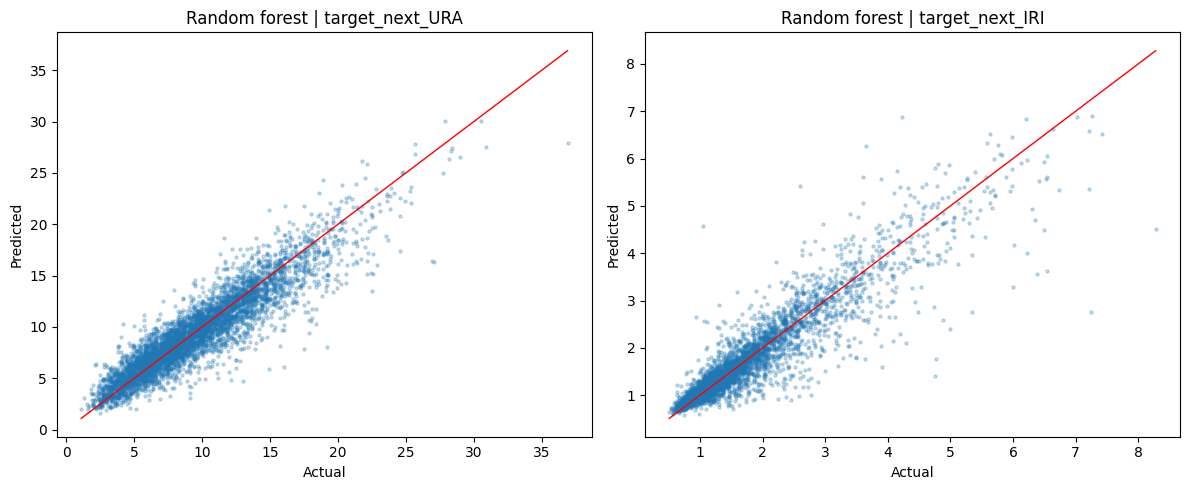

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, target_name in enumerate(["target_next_URA", "target_next_IRI"]):
    best_row = rf_results_df.loc[
        (rf_results_df["model"] == "random_forest") & (rf_results_df["target"] == target_name)
    ].sort_values("rmse").iloc[0]
    y_true, y_pred = rf_predictions[(best_row["feature_set"], target_name)]
    plot_df = pd.DataFrame({"actual": y_true, "predicted": y_pred}).sample(
        n=min(5000, len(y_true)),
        random_state=RANDOM_STATE,
    )

    ax = axes[idx]
    ax.scatter(plot_df["actual"], plot_df["predicted"], s=5, alpha=0.25)
    lo = min(plot_df["actual"].min(), plot_df["predicted"].min())
    hi = max(plot_df["actual"].max(), plot_df["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    ax.set_title(f"Random forest | {target_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()